In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the cleaned data with proper encoding
data_path = r'D:\PivotX_advisors\ai_cashflow_new_final.csv'
data2 = pd.read_csv(data_path)

df2 = data2.copy()
# df = df.sort_index()
print("HITACHI CASH FLOW FORECAST - DATA LOADED SUCCESSFULLY")

print(f"\nDataset Shape: {df2.shape[0]:,} rows × {df2.shape[1]} columns")
print(f"Memory Usage: {df2.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

HITACHI CASH FLOW FORECAST - DATA LOADED SUCCESSFULLY

Dataset Shape: 174,453 rows × 44 columns
Memory Usage: 463.78 MB


In [3]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174453 entries, 0 to 174452
Data columns (total 44 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   flow_category               136701 non-null  object 
 1   bank_branch_id              140653 non-null  object 
 2   source                      168156 non-null  object 
 3   instance                    134356 non-null  object 
 4   account                     140653 non-null  object 
 5   account_business_id         134356 non-null  object 
 6   id                          134356 non-null  object 
 7   source_primary_key          134356 non-null  object 
 8   source_file_name            134356 non-null  object 
 9   account_identifier          134356 non-null  object 
 10  transaction_currency        140653 non-null  object 
 11  transaction_amount          134356 non-null  float64
 12  value_datetime              134356 non-null  object 
 13  booking_dateti

In [ ]:
# # calculate the date range in df2
# # date_range = df2['value_datetime'].max() - df2['value_datetime'].min()
df2['value_datetime'] = pd.to_datetime(df2['value_datetime'], utc=True)
print(df2['value_datetime'].max(), df2['value_datetime'].min())
# # print(f"\nDate Range in df2: {date_range.days} days ({date_range})")

2026-01-30 00:00:00+00:00 2023-04-01 00:00:00+00:00


In [5]:
import pandas as pd

# Assuming 'df' is your DataFrame
results = []

for col in df2.columns:
    unique_count = df2[col].nunique()
    missing_values = df2[col].isnull().sum()
    
    # Logic: Get names if unique values < 10, otherwise show 'Too many'
    if unique_count < 20:
        unique_names = df2[col].unique().tolist()
        # Cleaning up the list for display (removing NaNs if you prefer)
        unique_names = [x for x in unique_names if pd.notnull(x)]
    else:
        unique_names = ">= 20 values"

    results.append({
        "Column": col,
        "Missing Values": missing_values,
        "Unique Count": unique_count,
        "Unique Values (<20)": unique_names
    })

# Convert to a DataFrame for a beautiful summary
summary_df = pd.DataFrame(results)


In [6]:
# Remove the limits on display
pd.set_option('display.max_rows', None)      # Show all rows
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.max_colwidth', None)  # Show full text in cells (don't truncate lists)

print(summary_df)

                        Column  Missing Values  Unique Count  \
0                flow_category           37752            50   
1               bank_branch_id           33800            86   
2                       source            6297             2   
3                     instance           40097             1   
4                      account           33800           205   
5          account_business_id           40097           205   
6                           id           40097        134356   
7           source_primary_key           40097        134356   
8             source_file_name           40097           898   
9           account_identifier           40097           210   
10        transaction_currency           33800            37   
11          transaction_amount           40097         61465   
12              value_datetime           40097           863   
13            booking_datetime            6447           904   
14                 description          

In [26]:
# Load the cleaned data with proper encoding
data_path = r'D:\PivotX_advisors\ai_cashflow_new.csv'
# data_path= r'D:\PivotX_advisors\fiscal_metrics_cashflow_default_flows.csv'
data = pd.read_csv(data_path)

df = data.copy()
# df = df.sort_index()
print("HITACHI CASH FLOW FORECAST - DATA LOADED SUCCESSFULLY")

print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

HITACHI CASH FLOW FORECAST - DATA LOADED SUCCESSFULLY

Dataset Shape: 174,453 rows × 44 columns
Memory Usage: 463.56 MB


In [4]:
# print(df2['Flow category'].value_counts(),len(df2['Flow category'].value_counts()))
# print(df['level5'].value_counts(),len(df['level5'].value_counts()))

# #find matching categories
# matching_categories = set(df2['Flow category']).intersection(set(df['level5']))
# print(f"\nMatching Categories ({len(matching_categories)}): {matching_categories}")

In [5]:
# # Define a mapping to standardize the names
# import pandas as pd

# # 1. Ensure date columns are in datetime format with UTC
# df['value_datetime'] = pd.to_datetime(df['value_datetime'], utc=True)
# df2['Value datetime'] = pd.to_datetime(df2['Value datetime'], utc=True)
# df2.rename(columns={'Flow category': 'level5'}, inplace=True)
# df2 = df2.rename(columns={
#     'Value datetime': 'value_datetime',
#     'Account': 'account_name',
#     'Transaction amount': 'transaction_amount'
# })
# category_mapping = {
#     # df2 name : Standardized name
#     'Interco Payments - Div': 'Interco Payments - Dividends',
#     'Interco Receipts - Div': 'Interco Receipts - Dividends',
#     'Product Pmts Hitachi Grp': 'Product Payments - Hitachi Ltd Group',
#     'Adjustment to GL': 'Adjustment to Reconcile Bank Activity to GL',
#     'Inc/Decr 3rd Part Loans': 'Increase (Decrease) - Loans from 3rd Party Lenders',
#     'Withdrawal/dep Cash Pool': 'Withdrawal (deposit) - Cash pool header',
#     'A/R Sales Proceeds': 'A/R Sales - Proceeds from true sales of A/R',
#     'Reimb from Hitachi Grp': 'Reimbursements from Hitachi Ltd Group',
#     'Dividend Rec Hitachi Grp': 'Dividends Received from HITACHI LTD Group',
#     'Other Pmts to Hitachi Grp': 'Non Product/Other Payments to Hitachi Ltd Group',
#     'Pmt for true sales of A/R': 'Payments for true sales of A/R',
#     'Lease Sales Proceeds Rec': 'Lease Sales - Proceeds Received',
#     'Inc/Decr LT w Hit Fin': 'Increase (Decrease) - Long Term Loans from Hitachi Finance',
#     'Inc/Decr Dep w Hit Fin': 'Increase (Decrease) - Deposits with Hitachi Finance',
#     'Inc/Decr ST w Hit Fin': 'Increase (Decrease) - ST/Revolving Loans from Hitachi Finance',
#     'Inc/Decr Other Financing': 'Increase (Decrease) - Other Financing',
#     'A/R Financing - A/R Purch': 'A/R Financing - A/R Purchased by Bank',
#     'A/R Financing - Repayment': 'A/R Financing - Repayment to Bank',
#     'Capital Contributions Rec': 'Capital Contributions Received',
#     'Capital Contributions Pd': 'Capital Contributions Made'
# }

# # Apply mapping to df2 (assuming df holds the "full" names)
# df2['level5'] = df2['level5'].replace(category_mapping)

# # Clean up any trailing spaces which often break merges
# df['level5'] = df['level5'].str.strip()
# df2['level5'] = df2['level5'].str.strip()

In [6]:
# #now combing the two datasets based on the account name , date and category
# #first we need to convert the date columns to datetime format
# print(f"\nBefore Merging - Dataset 1 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
# print(df2['Value datetime'].dtype)
# #convert the df2 date columns to datetime format datetime64[ns, UTC] from datetime64[ns]


# print(df['value_datetime'].dtype)
# df['value_datetime'] = pd.to_datetime(df['value_datetime'], utc=True)
# df2['Value datetime'] = pd.to_datetime(df2['Value datetime'], utc=True)
# #first rename the columns in df2 to match with df
# df2.rename(columns={'Flow category': 'level5'}, inplace=True)
# #now we can merge the two datasets based on the account name , date and category
# merged_df = pd.merge(df, df2, left_on=['value_datetime', 'account_name'], right_on=['Value datetime', 'Account'], how='inner')
# print(f"\nMerged Dataset Shape: {merged_df.shape[0]:,} rows × {merged_df.shape[1]} columns")

In [4]:
df.columns.tolist()

['flow_category',
 'bank_branch_id',
 'source',
 'instance',
 'account',
 'account_business_id',
 'id',
 'source_primary_key',
 'source_file_name',
 'account_identifier',
 'transaction_currency',
 'transaction_amount',
 'value_datetime',
 'booking_datetime',
 'description',
 'extended_details',
 'canonical_update_timestamp',
 'account_name',
 'account_alternative_name',
 'account_holder',
 'account_holder_id',
 'account_class',
 'cash_pool_role',
 'cash_pool_name',
 'bank_name',
 'account_currency',
 'entity_country',
 'entity_name',
 'entity_alternative_name',
 'entity_code',
 'entity_currency',
 'entity_region',
 'entity_top_level',
 'branch_name',
 'level1',
 'level2',
 'level3',
 'level4',
 'level5',
 'fx_rate',
 'transaction_amount_usd',
 'forecast_flag',
 'opcos',
 'period_month',
 'date']

In [8]:
df.head()

,flow_category,bank_branch_id,source,instance,account,account_business_id,id,source_primary_key,source_file_name,account_identifier,...,level1,level2,level3,level4,level5,fx_rate,transaction_amount_usd,forecast_flag,opcos,period_month
0,NaN,NaN,Forecast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,A/R - Collections,NaN,0.0,ai_forecast,HV,JAN-26
1,NaN,NaN,Forecast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,AP - OPEX Payments,NaN,0.0,ai_forecast,HV,JAN-26
2,NaN,NaN,Forecast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Increase (Decrease) - ST/Revolving Loans from ...,NaN,0.0,ai_forecast,HV,JAN-26
3,NaN,NaN,Forecast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Interco Payments - Loan,NaN,0.0,ai_forecast,HV,JAN-26
4,NaN,NaN,Forecast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Interco Payments - Trade,NaN,0.0,ai_forecast,HV,JAN-26


In [9]:
import pandas as pd

# Assuming 'df' is your DataFrame
results = []

for col in df.columns:
    unique_count = df[col].nunique()
    missing_values = df[col].isnull().sum()
    
    # Logic: Get names if unique values < 10, otherwise show 'Too many'
    if unique_count < 20:
        unique_names = df[col].unique().tolist()
        # Cleaning up the list for display (removing NaNs if you prefer)
        unique_names = [x for x in unique_names if pd.notnull(x)]
    else:
        unique_names = ">= 20 values"

    results.append({
        "Column": col,
        "Missing Values": missing_values,
        "Unique Count": unique_count,
        "Unique Values (<20)": unique_names
    })

# Convert to a DataFrame for a beautiful summary
summary_df = pd.DataFrame(results)


In [10]:
# Remove the limits on display
pd.set_option('display.max_rows', None)      # Show all rows
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.max_colwidth', None)  # Show full text in cells (don't truncate lists)

print(summary_df)

                        Column  Missing Values  Unique Count  \
0                flow_category           37752            50   
1               bank_branch_id           33800            86   
2                       source            6297             2   
3                     instance           40097             1   
4                      account           33800           205   
5          account_business_id           40097           205   
6                           id           40097        134356   
7           source_primary_key           40097        134356   
8             source_file_name           40097           898   
9           account_identifier           40097           210   
10        transaction_currency           33800            37   
11          transaction_amount           40097         61465   
12              value_datetime           40097           863   
13            booking_datetime            6447           904   
14                 description          

In [27]:
df['value_datetime'] = pd.to_datetime(df['value_datetime'], utc=True)
print(df['value_datetime'].min(), df['value_datetime'].max())
print(df['value_datetime'].max() - df['value_datetime'].min())

2023-04-01 00:00:00+00:00 2026-01-30 00:00:00+00:00
1035 days 00:00:00


In [12]:
print(df['level5'].value_counts())

level5
AP - OPEX Payments                                            17330
Interco Receipts - Loan                                       17097
Interco Payments - Loan                                       17082
A/R - Collections                                             16906
Miscellaneous Disbursements                                   14052
Miscellaneous Receipts                                        13063
Payroll Payments                                              11213
Tax Payments                                                  10587
Interco Payments - Trade                                       9198
Interco Receipts - Trade                                       8906
Product Payments - Hitachi Ltd Group                           5147
Interco Payments - Dividends                                   5119
Interco Receipts - Dividends                                   5067
Adjustment to Reconcile Bank Activity to GL                    5059
Related Parties - Receipts               

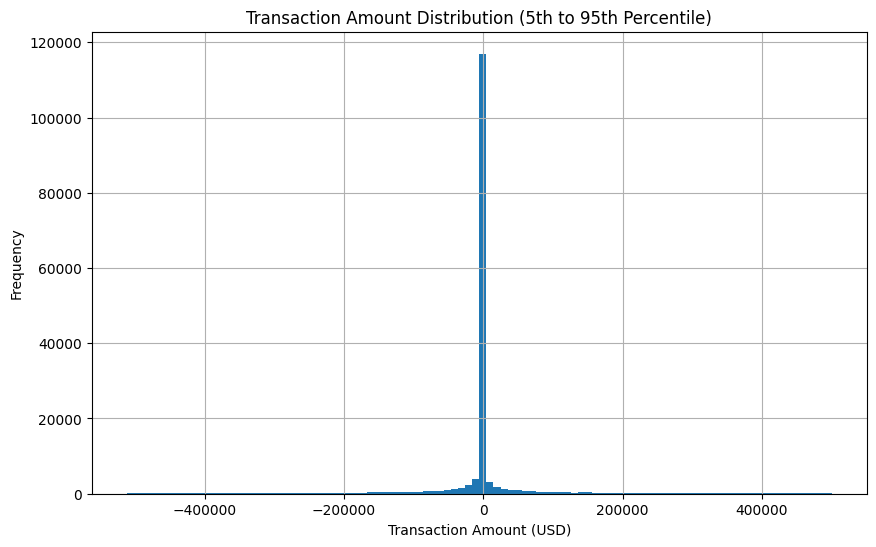

In [13]:
# Calculate percentiles
lower = df['transaction_amount_usd'].quantile(0.05)
upper = df['transaction_amount_usd'].quantile(0.95)

# Filter for the "Middle 90%"
filtered_df = df[(df['transaction_amount_usd'] > lower) & 
                         (df['transaction_amount_usd'] < upper)]

filtered_df['transaction_amount_usd'].hist(bins=100, figsize=(10, 6))
plt.title(f'Transaction Amount Distribution (5th to 95th Percentile)')
plt.xlabel('Transaction Amount (USD)')
plt.ylabel('Frequency')
plt.show()

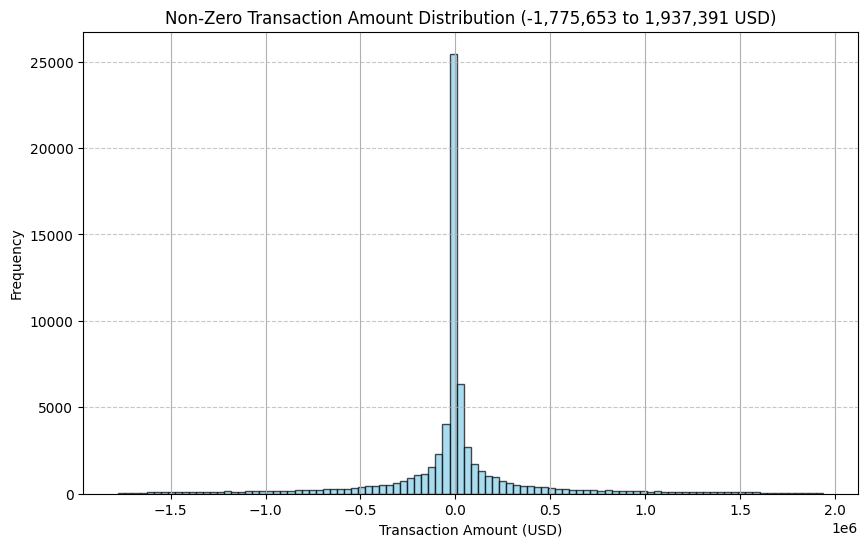

In [14]:
import matplotlib.pyplot as plt

# 1. Remove zero transactions first
# This clears the 'noise' so we only see actual money moving
df_non_zero = df[df['transaction_amount_usd'] != 0]

# 2. Calculate percentiles on the NON-ZERO data
# This gives a much more accurate 'Middle 90%' range
lower = df_non_zero['transaction_amount_usd'].quantile(0.05)
upper = df_non_zero['transaction_amount_usd'].quantile(0.95)

# 3. Filter for the "Middle 90%" of these active transactions
filtered_df = df_non_zero[(df_non_zero['transaction_amount_usd'] > lower) & 
                          (df_non_zero['transaction_amount_usd'] < upper)]

# 4. Create the plot
plt.figure(figsize=(10, 6))
filtered_df['transaction_amount_usd'].hist(bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f'Non-Zero Transaction Amount Distribution ({lower:,.0f} to {upper:,.0f} USD)')
plt.xlabel('Transaction Amount (USD)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [15]:
import pandas as pd

# List of columns you want to analyze
target_columns = ['source', 'flow_category','level5','level2','entity_name', 'entity_type', 'bank_name']

# Ensure only existing columns are processed
existing_cols = [col for col in target_columns if col in df.columns]

print("--- Categorical Distributions ---\n")

for col in existing_cols:
    # 1. Calculate counts and percentages
    counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(dropna=False, normalize=True) * 100
    
    # 2. Combine into a nice distribution table
    dist_df = pd.concat([counts, percentages], axis=1)
    dist_df.columns = ['Count', 'Percentage (%)']
    
    # 3. Print with formatting
    print(f"Column: {col}")
    # If the column has many unique values, you might only want the top 15
    if len(dist_df) > 15:
        print(dist_df.head(15))
        print(f"... and {len(dist_df) - 15} more unique values.")
    else:
        print(dist_df)
    print("-" * 30 + "\n")

--- Categorical Distributions ---

Column: source
           Count  Percentage (%)
source                          
OAT       134356       77.015586
Forecast   33800       19.374846
NaN         6297        3.609568
------------------------------

Column: flow_category
                          Count  Percentage (%)
flow_category                                  
NaN                       37752       21.640213
AP - OPEX Payments        14324        8.210807
Interco Receipts - Loan   14109        8.087565
Interco Payments - Loan   14094        8.078967
A/R - Collections         13901        7.968335
Misc Disbursements        11124        6.376503
Miscellaneous Receipts    10075        5.775194
Payroll Payments           8215        4.709005
Tax Payments               7595        4.353608
Interco Payments - Trade   6195        3.551100
Interco Receipts - Trade   5903        3.383719
Product Pmts Hitachi Grp   5147        2.950365
Interco Payments - Div     5093        2.919411
Interco Rec

| Code | Full Name | What it Represents |
| :--- | :--- | :--- |
| **OAB** | Open Account Balances | The "snapshot." These are the starting or current balances of your accounts at a specific point in time (e.g., what is currently in the bank). |
| **OAT** | Other Actuals Transactions | The "movement." These are the individual line-item transactions (receipts, invoices, payments) that have actually happened. |
| **OFT** | Other Forecast Data | The "future." This contains your budget, projections, or estimated future spend/revenue. |

In [28]:
# keep source only "OAT"
df = df[df['source'] == 'OAT'].copy()

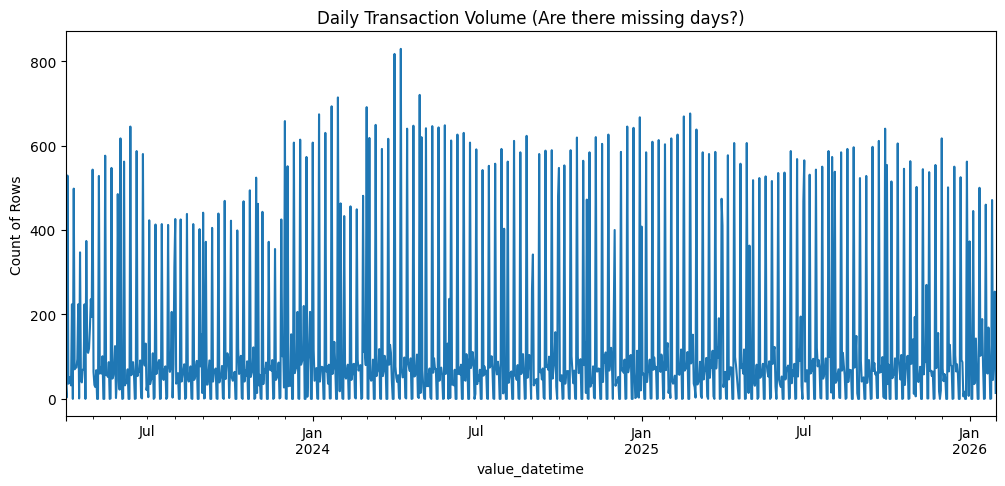

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert date column
df['value_datetime'] = pd.to_datetime(df['value_datetime'])

# 1. Timeline of Data Density
plt.figure(figsize=(12, 5))
df.set_index('value_datetime').resample('D').size().plot()
plt.title('Daily Transaction Volume (Are there missing days?)')
plt.ylabel('Count of Rows')
plt.show()

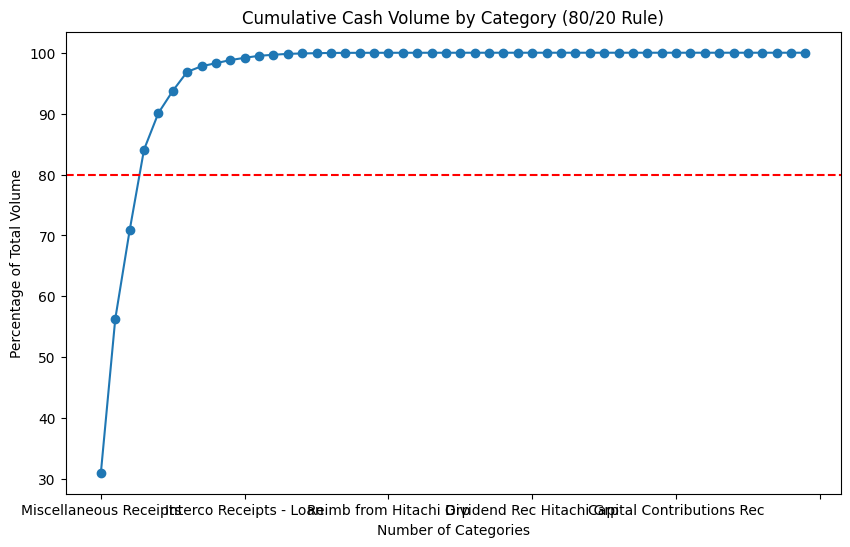

In [18]:
# Group by category and sum absolute values (to treat payments and receipts equally)
cat_analysis = df.groupby('flow_category')['transaction_amount'].apply(lambda x: x.abs().sum()).sort_values(ascending=False)
cat_perc = (cat_analysis.cumsum() / cat_analysis.sum()) * 100

plt.figure(figsize=(10, 6))
cat_perc.plot(kind='line', marker='o')
plt.axhline(80, color='r', linestyle='--')
plt.title('Cumulative Cash Volume by Category (80/20 Rule)')
plt.ylabel('Percentage of Total Volume')
plt.xlabel('Number of Categories')
plt.show()

In [19]:
def quality_audit(df):
    print("--- Data Quality Audit ---")
    # 1. Zero Amounts (Usually noise)
    zeros = (df['transaction_amount'] == 0).sum()
    print(f"Rows with 0.00 amount: {zeros}")
    

    
    # # 2. Currency Mismatches
    # # Checking if an entity uses more than one currency (can complicate models)
    # ent_curr = df.groupby('entity_name')['currency'].nunique()
    # multi_curr = ent_curr[ent_curr > 1].count()
    # print(f"Entities using multiple currencies: {multi_curr}")

quality_audit(df)

--- Data Quality Audit ---
Rows with 0.00 amount: 63923


In [20]:
# Missing Values Analysis

print("MISSING VALUES ANALYSIS")

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})

# Sort by missing percentage descending
missing_data = missing_data.sort_values('Missing_Percentage', ascending=False)

print(f"\nTotal Missing Values in Dataset: {df.isnull().sum().sum():,}")
print(f"Columns with No Missing Values: {(missing_data['Missing_Count'] == 0).sum()}")
print(f"Columns with >50% Missing Values: {(missing_data['Missing_Percentage'] > 50).sum()}")

MISSING VALUES ANALYSIS

Total Missing Values in Dataset: 175,870
Columns with No Missing Values: 29
Columns with >50% Missing Values: 2


In [21]:
print("DETAILED DATA STRUCTURE ANALYSIS")


# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
# Categorical Features Analysis

print("CATEGORICAL FEATURES ANALYSIS")

for col in categorical_cols:
    unique_count = df[col].nunique()
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100
    
    print(f"\n{col}:")
    print(f"  Unique Values: {unique_count}")
    print(f"  Null Values: {null_count} ({null_pct:.2f}%)")
    print(f"  Top 5 Values:")
    top_vals = df[col].value_counts().head(5)
    for val, count in top_vals.items():
        pct = (count / (len(df) - null_count)) * 100
        print(f"    - {val}: {count:,} ({pct:.1f}%)")


DETAILED DATA STRUCTURE ANALYSIS
CATEGORICAL FEATURES ANALYSIS

flow_category:
  Unique Values: 50
  Null Values: 1 (0.00%)
  Top 5 Values:
    - AP - OPEX Payments: 14,324 (10.7%)
    - Interco Receipts - Loan: 14,109 (10.5%)
    - Interco Payments - Loan: 14,094 (10.5%)
    - A/R - Collections: 13,901 (10.3%)
    - Misc Disbursements: 10,727 (8.0%)

bank_branch_id:
  Unique Values: 86
  Null Values: 0 (0.00%)
  Top 5 Values:
    - CITIBANK N.A., LONDON BRANCH: 16,403 (12.2%)
    - (BANK OF AMERICA): 9,192 (6.8%)
    - (JPMORGAN CHASE BANK, N.A. NEW YORK BRANCH): 6,164 (4.6%)
    - CITIBANK EUROPE PLC, NETHERLANDS BRANCH: 5,125 (3.8%)
    - (JP MORGAN CHASE BANK, N.A., SINGAPORE BRANCH): 5,028 (3.7%)

source:
  Unique Values: 1
  Null Values: 0 (0.00%)
  Top 5 Values:
    - OAT: 134,356 (100.0%)

instance:
  Unique Values: 1
  Null Values: 0 (0.00%)
  Top 5 Values:
    - Other_Actuals_Trans: 134,356 (100.0%)

account:
  Unique Values: 205
  Null Values: 0 (0.00%)
  Top 5 Values:
    -

In [22]:
# i want to map level 5 categories with level 2 categories to see if there is a pattern in the data
mapping = df.groupby('level5')['level2'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
print(mapping)

level5
A/R - Collections                                               Free Cash Flow
A/R Financing - A/R Purchased by Bank                          Financing Flows
A/R Financing - Repayment to Bank                              Financing Flows
A/R Sales - Proceeds from true sales of A/R                     Free Cash Flow
AP - OPEX Payments                                              Free Cash Flow
AP CAPEX Payments                                                  Investments
Adjustment to Reconcile Bank Activity to GL                     Free Cash Flow
Capital Contributions Made                                         Investments
Capital Contributions Received                                     Investments
Dividends Received from HITACHI LTD Group                       Free Cash Flow
Increase (Decrease) - Deposits with Hitachi Finance            Financing Flows
Increase (Decrease) - Loans from 3rd Party Lenders             Financing Flows
Increase (Decrease) - Long Term Loans from Hi

In [23]:
# # i want to check dates for which fx rates are missing to see if there is a pattern in the data
# missing_fx_dates = df[df['fx_rate'].isnull()]['value_datetime'].dt.date.value_counts()
# print(missing_fx_dates)

# missing_fx_currencies = df[df['fx_rate'].isnull()]['transaction_currency']
# print(missing_fx_currencies.value_counts())

In [24]:
# # i want to see unique fx_rates values for the transaction_currency combinations to see if there is a pattern in the data
# fx_rate_combinations = df.groupby('transaction_currency')['fx_rate'].unique()
# print(fx_rate_combinations)

In [25]:
# Fix dirty '0' currency values → treat as USD
df['transaction_currency'] = df['transaction_currency'].replace('0', 'USD')

In [26]:
# avg_exchange_rates = {
#     'aed': {'2023': 1/3.673,    '2024': 1/3.673,    '2025': 1/3.673,    '2026': 1/3.673},
#     'ars': {'2023': 1/296.260,  '2024': 1/915.161,  '2025': 1/1243.369, '2026': 1/1243.369},
#     'aud': {'2023': 1/1.506,    '2024': 1/1.516,    '2025': 1/1.551,    '2026': 1/1.551},
#     'brl': {'2023': 1/4.994,    '2024': 1/5.392,    '2025': 1/5.593,    '2026': 1/5.593},
#     'cad': {'2023': 1/1.350,    '2024': 1/1.370,    '2025': 1/1.398,    '2026': 1/1.398},
#     'clp': {'2023': 1/839.490,  '2024': 1/943.79,   '2025': 1/894.87,   '2026': 1/894.87},
#     'ils': {'2023': 1/3.667,    '2024': 1/3.701,    '2025': 1/3.451,    '2026': 1/3.451},
#     'inr': {'2023': 1/82.601,   '2024': 1/83.677,   '2025': 1/87.133,   '2026': 1/87.133},
#     'kes': {'2023': 1/122.830,  '2024': 1/134.88,   '2025': 1/129.31,   '2026': 1/129.31},
#     'krw': {'2023': 1/1305.66,  '2024': 1/1364.15,  '2025': 1/1421.78,  '2026': 1/1421.78},
#     'ngn': {'2023': 1/461.530,  '2024': 1/1465.04,  '2025': 1/1522.46,  '2026': 1/1522.46},
#     'nzd': {'2023': 1/1.628,    '2024': 1/1.654,    '2025': 1/1.719,    '2026': 1/1.719},
#     'php': {'2023': 1/55.630,   '2024': 1/57.310,   '2025': 1/57.503,   '2026': 1/57.503},
#     'thb': {'2023': 1/34.800,   '2024': 1/35.267,   '2025': 1/32.870,   '2026': 1/32.870},
#     'try': {'2023': 1/23.082,   '2024': 1/32.867,   '2025': 1/39.546,   '2026': 1/39.546},
#     'twd': {'2023': 1/31.157,   '2024': 1/32.117,   '2025': 1/31.167,   '2026': 1/31.167},
#     'usd': {'2023': 1/1.0,      '2024': 1/1.0,      '2025': 1/1.0,      '2026': 1/1.0},
#     'vnd': {'2023': 1/23400.0,  '2024': 1/23450.0,  '2025': 1/23450.0,  '2026': 1/23450.0},
#     'eur': {'2023': 1/1.081,    '2024': 1/1.085,    '2025': 1/1.052,    '2026': 1/1.052},
#     'gbp': {'2023': 1/1.244,    '2024': 1/1.279,    '2025': 1/1.284,    '2026': 1/1.284},
# }

# def fill_fx_rate(row):
#     if pd.isnull(row['fx_rate']):
#         currency = str(row['transaction_currency']).lower()  # handles case mismatch
#         year = str(row['value_datetime'].year)
#         if currency in avg_exchange_rates and year in avg_exchange_rates[currency]:
#             return avg_exchange_rates[currency][year]
#     return row['fx_rate']

# df['fx_rate'] = df.apply(fill_fx_rate, axis=1)
# # i want to check dates for which fx rates are missing to see if there is a pattern in the data
# missing_fx_dates = df[df['fx_rate'].isnull()]['value_datetime'].dt.date.value_counts()
# print(missing_fx_dates)

# missing_fx_currencies = df[df['fx_rate'].isnull()]['transaction_currency']
# print(missing_fx_currencies.value_counts())

In [27]:
print(df['fx_rate'].isnull().sum())
print(df['transaction_currency'].isnull().sum())

70
0


In [29]:
# # Fill missing transaction_amount_usd using transaction_amount * fx_rate
# df['transaction_amount_usd'] = df['transaction_amount_usd'].fillna(
#     df['transaction_amount'] * df['fx_rate']
# )

# Verify
print(df['transaction_amount_usd'].isnull().sum())  # should be 0 or close to 0

70


In [30]:
# Drop rows where critical modeling data is missing
df_clean = df.dropna(subset=['transaction_amount_usd', 'value_datetime'])

print(f"Removed {len(df) - len(df_clean)} rows.")
print(f"Remaining rows: {len(df_clean)}")

Removed 70 rows.
Remaining rows: 134286


In [31]:
# Create a text-based flag
df_clean['cash_direction'] = df_clean['transaction_amount_usd'].apply(lambda x: 'Inflow' if x > 0 else 'Outflow')

# Check the distribution
print(df_clean['cash_direction'].value_counts())

cash_direction
Outflow    103839
Inflow      30447
Name: count, dtype: int64


In [32]:
# add flow category from same row to missing level5
df_clean['level5'] = df_clean.apply(lambda row: row['flow_category'] if pd.isnull(row['level5']) else row['level5'], axis=1)

In [32]:
df_clean.head()

,flow_category,bank_branch_id,source,instance,account,account_business_id,id,source_primary_key,source_file_name,account_identifier,transaction_currency,transaction_amount,value_datetime,booking_datetime,description,extended_details,canonical_update_timestamp,account_name,account_alternative_name,account_holder,account_holder_id,account_class,cash_pool_role,cash_pool_name,bank_name,account_currency,entity_country,entity_name,entity_alternative_name,entity_code,entity_currency,entity_region,entity_top_level,branch_name,level1,level2,level3,level4,level5,fx_rate,transaction_amount_usd,forecast_flag,opcos,period_month,cash_direction
33872,NaN,"CITIBANK N.A., LONDON BRANCH",OAT,Other_Actuals_Trans,17467060,17467060,OAT/168d3189-e91b-4ee2-a17c-2b82ecf24099/#N/A,OAT/168d3189-e91b-4ee2-a17c-2b82ecf24099/#N/A,Jan25ActualsEMEAfinal_oat_2025-02-07_18-21-00.csv,17467060,USD,0.00,2025-01-17 00:00:00+00:00,2025-01-17 00:00:00 UTC,Wk3_Jan 25,{},2025-02-07T17:26:10.297884,17467060,Current_Disbursement_USD_7060,HITACHI VANTARA LLC (EMEA US branch) 160,HITACHI VANTARA LLC (EMEA US branch) 160,Physical,NaN,NaN,Citibank,usd,US EMEA,HITACHI VANTARA LLC (EMEA US branch) 160,160 - EMEA US Br. (7033),160.0,eur,EMEA,Hitachi,"CITIBANK N.A., LONDON BRANCH",Default flows,Default flows,4.1 Default flows,Default flows,Unallocated,1.00000,0.000000,actuals,HV,JAN-25,Outflow
33873,A/R - Collections,"CITIBANK N.A., LONDON BRANCH",OAT,Other_Actuals_Trans,15040493,15040493,OAT/168d3189-e91b-4ee2-a17c-2b82ecf24099/00230_EUR_15040493_20241104_A/R - Collections,OAT/168d3189-e91b-4ee2-a17c-2b82ecf24099/00230_EUR_15040493_20241104_A/R - Collections,Nov24ActualsEMEADS_OAT_2024-12-05_00-00-00.csv,15040493,EUR,23249.55,2024-11-04 00:00:00+00:00,2024-11-04 00:00:00 UTC,Wk2_Nov 24,{},2024-12-05T12:38:24.501067,15040493,Current_Main Account_EUR_0493,Hitachi Digital Services UK Ltd 00230,Hitachi Digital Services UK Ltd 00230,Physical,Sub-account,DS EMEA Cash Pool (EUR),Citibank,eur,United Kingdom,Hitachi Digital Services UK Ltd 00230,00230 - DS UK (6040),230.0,gbp,EMEA,Hitachi,"CITIBANK N.A., LONDON BRANCH",Cash from Operations,Free Cash Flow,1.1 Physical Cash Receipts,Collections Receipts,A/R - Collections,1.08696,25271.330868,actuals,HDS,NOV-24,Inflow
33874,A/R - Collections,"CITIBANK N.A., LONDON BRANCH",OAT,Other_Actuals_Trans,15040493,15040493,OAT/168d3189-e91b-4ee2-a17c-2b82ecf24099/00230_EUR_15040493_20241111_A/R - Collections,OAT/168d3189-e91b-4ee2-a17c-2b82ecf24099/00230_EUR_15040493_20241111_A/R - Collections,Nov24ActualsEMEADS_OAT_2024-12-05_00-00-00.csv,15040493,EUR,111961.94,2024-11-11 00:00:00+00:00,2024-11-11 00:00:00 UTC,Wk3_Nov 24,{},2024-12-05T12:38:24.501067,15040493,Current_Main Account_EUR_0493,Hitachi Digital Services UK Ltd 00230,Hitachi Digital Services UK Ltd 00230,Physical,Sub-account,DS EMEA Cash Pool (EUR),Citibank,eur,United Kingdom,Hitachi Digital Services UK Ltd 00230,00230 - DS UK (6040),230.0,gbp,EMEA,Hitachi,"CITIBANK N.A., LONDON BRANCH",Cash from Operations,Free Cash Flow,1.1 Physical Cash Receipts,Collections Receipts,A/R - Collections,1.08696,121698.150302,actuals,HDS,NOV-24,Inflow
33875,AP - OPEX Payments,"CITIBANK N.A., LONDON BRANCH",OAT,Other_Actuals_Trans,15040493,15040493,OAT/168d3189-e91b-4ee2-a17c-2b82ecf24099/00230_EUR_15040493_20241125_AP - OPEX Payments,OAT/168d3189-e91b-4ee2-a17c-2b82ecf24099/00230_EUR_15040493_20241125_AP - OPEX Payments,Nov24ActualsEMEADS_OAT_2024-12-05_00-00-00.csv,15040493,EUR,-52710.72,2024-11-25 00:00:00+00:00,2024-11-25 00:00:00 UTC,Wk5_Nov 24,{},2024-12-05T12:38:24.501067,15040493,Current_Main Account_EUR_0493,Hitachi Digital Services UK Ltd 00230,Hitachi Digital Services UK Ltd 00230,Physical,Sub-account,DS EMEA Cash Pool (EUR),Citibank,eur,United Kingdom,Hitachi Digital Services UK Ltd 00230,00230 - DS UK (6040),230.0,gbp,EMEA,Hitachi,"CITIBANK N.A., LONDON BRANCH",Cash from Operations,Free Cash Flow,2.1.1 Payments on behalf (POBO),Payables,AP - OPEX Payments,1.08696,-57294.444211,actuals,HDS,NOV-

In [33]:
selected_columns = [
    'opcos',
    'entity_region',
    'entity_country',
    'entity_name',
    'account_name',
    'source', 
    'level2',
    'level5',
    'transaction_currency', 
    'cash_direction',
    'transaction_amount_usd', 
    'value_datetime'
    
]
# Create a slimmed-down version of the dataframe
df_final = df_clean[selected_columns].copy()

# # 3. Separate the dataframes
# df_digital = df_final[df_final['parent_entity'] == 'Hitachi Digital Services']
# df_vantara = df_final[df_final['parent_entity'] == 'HITACHI VANTARA']

# # 4. Store in CSV
# df_digital.to_csv('hitachi_digital_services_data.csv', index=False)
# df_vantara.to_csv('hitachi_vantara_data.csv', index=False)
# df_final.to_csv('hitachi_cash_flow_data_final.csv', index=False)
# print(f"Success! Created final files:")
# print(f"- 'hitachi_digital_services_data.csv' ({len(df_digital)} rows)")
# print(f"- 'hitachi_vantara_data.csv' ({len(df_vantara)} rows)")

In [11]:
df_final.head()

,opcos,entity_region,entity_country,entity_name,account_name,source,level2,level5,transaction_currency,cash_direction,transaction_amount_usd,value_datetime
0,HV,AMER,US,HITACHI VANTARA LLC 110,1233103167,OAT,Investments,Payments for M&A Activities,usd,Outflow,0.0,2025-08-18 00:00:00+00:00
1,HV,AMER,US,HITACHI VANTARA LLC 110,1233103167,OAT,Investments,Payments for M&A Activities,usd,Outflow,0.0,2025-08-25 00:00:00+00:00
2,HV,AMER,US,HITACHI VANTARA LLC 110,1233103167,OAT,Investments,Capital Contributions Received,usd,Outflow,0.0,2025-08-01 00:00:00+00:00
3,HV,AMER,US,HITACHI VANTARA LLC 110,1233103167,OAT,Investments,Capital Contributions Received,usd,Outflow,0.0,2025-08-04 00:00:00+00:00
4,HV,AMER,US,HITACHI VANTARA LLC 110,1233103167,OAT,Investments,Capital Contributions Received,usd,Outflow,0.0,2025-08-11 00:00:00+00:00


In [44]:
level2_map = {
    'A/R - Collections': 'Free Cash Flow',
    'A/R Financing - A/R Purchased by Bank': 'Financing Flows',
    'A/R Financing - Repayment to Bank': 'Financing Flows',
    'A/R Sales - Proceeds from true sales of A/R': 'Free Cash Flow',
    'AP - OPEX Payments': 'Free Cash Flow',
    'AP CAPEX Payments': 'Investments',
    'Adjustment to Reconcile Bank Activity to GL': 'Free Cash Flow',
    'Capital Contributions Made': 'Investments',
    'Capital Contributions Received': 'Investments',
    'Dividends Received from HITACHI LTD Group': 'Free Cash Flow',
    'Increase (Decrease) - Deposits with Hitachi Finance': 'Financing Flows',
    'Increase (Decrease) - Loans from 3rd Party Lenders': 'Financing Flows',
    'Increase (Decrease) - Long Term Loans from Hitachi Finance': 'Financing Flows',
    'Increase (Decrease) - Other Financing': 'Financing Flows',
    'Increase (Decrease) - ST/Revolving Loans from Hitachi Fin': 'Financing Flows',
    'Interco Payments - Dividends': 'Interco Payments',
    'Interco Payments - Loan': 'Interco Payments',
    'Interco Payments - Trade': 'Interco Payments',
    'Interco Receipts - Dividends': 'Interco Receipts',
    'Interco Receipts - Loan': 'Interco Receipts',
    'Interco Receipts - Trade': 'Interco Receipts',
    'Interest Expense Paid': 'Free Cash Flow',
    'Interest Income': 'Free Cash Flow',
    'Lease Sales - Proceeds Received': 'Free Cash Flow',
    'Miscellaneous Disbursements': 'Free Cash Flow',
    'Miscellaneous Receipts': 'Free Cash Flow',
    'Non Product/Other Payments to Hitachi Ltd Group': 'Free Cash Flow',
    'Other Financial Flows': 'Financing Flows',
    'Payments for Lease Sales': 'Free Cash Flow',
    'Payments for M&A Activities': 'Investments',
    'Payments for true sales of A/R': 'Free Cash Flow',
    'Payroll Payments': 'Free Cash Flow',
    'Product Payments - Hitachi Ltd Group': 'Free Cash Flow',
    'Reimbursements from Hitachi Ltd Group': 'Free Cash Flow',
    'Related Parties - Payments': 'Free Cash Flow',
    'Related Parties - Receipts': 'Free Cash Flow',
    'Tax Payments': 'Free Cash Flow',
    'Tax Refunds': 'Free Cash Flow',
    'Unallocated': 'Default flows',
    'Withdrawal (deposit) - Cash pool header': 'Interco Payments',
}
df_final['level5'] = df_final['level5'].replace({
    'A/R - Collections       ': 'A/R - Collections',
    'A/R - Collections ': 'A/R - Collections',
    'Tax Payments          ': 'Tax Payments'
})
#add level2 map where values are missing
df_final['level2'] = df_final['level2'].fillna(
    df_final['level5'].map(level2_map)
)

In [45]:
level2_map = (
    df_final.dropna(subset=['level2'])   # keep only rows where level2 exists
    .drop_duplicates(subset=['level5'])  # avoid duplicate keys
    .set_index('level5')['level2']       # create mapping
)
df_final['level2'] = df_final['level2'].fillna(
    df_final['level5'].map(level2_map)
)

In [34]:
import pandas as pd

# Assuming 'df' is your DataFrame
results_df_final = []

for col in df_final.columns:
    unique_count = df_final[col].nunique()
    missing_values = df_final[col].isnull().sum()
    

    results_df_final.append({
        "Column": col,
        "Missing Values": missing_values,
        "Unique Count": unique_count})

# Convert to a DataFrame for a beautiful summary
summary_df_final = pd.DataFrame(results_df_final)


In [35]:
# Remove the limits on display
pd.set_option('display.max_rows', None)      # Show all rows
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.max_colwidth', None)  # Show full text in cells (don't truncate lists)

print(summary_df_final)

                    Column  Missing Values  Unique Count
0                    opcos            3692             2
1            entity_region               0             3
2           entity_country               0            44
3              entity_name               0            77
4             account_name               0           198
5                   source               0             1
6                   level2              45             6
7                   level5               0            45
8     transaction_currency               0            36
9           cash_direction               0             2
10  transaction_amount_usd               0         65904
11          value_datetime               0           863


In [36]:
# Drop rows where critical modeling data is missing
df_final = df_final.dropna(subset=['opcos'])
df_final = df_final.dropna(subset=['level2'])

In [51]:
df_final['level5'].value_counts()

level5
AP - OPEX Payments                                            14004
Interco Receipts - Loan                                       13884
Interco Payments - Loan                                       13869
A/R - Collections                                             13657
Miscellaneous Disbursements                                   10807
Miscellaneous Receipts                                         9799
Payroll Payments                                               7976
Tax Payments                                                   7263
Interco Payments - Trade                                       5960
Interco Receipts - Trade                                       5658
Product Payments - Hitachi Ltd Group                           4535
Interco Payments - Dividends                                   4506
Interco Receipts - Dividends                                   4456
Adjustment to Reconcile Bank Activity to GL                    4439
Increase (Decrease) - Loans from 3rd Part

In [18]:
# df_final=df_final[df['transaction_amount_usd']!=0]
len(df_final)

136506

In [57]:
# #  Store in CSV

df_final.to_csv('hitachi_clean_final_usd___level_5_new.csv', index=False)
print(f"Success! Created final files: hitachi_clean_final_usd___level_5.csv")

Success! Created final files: hitachi_clean_final_usd___level_5.csv


In [43]:
# Create weekly date column (Monday-aligned)
df_final['date'] = (
    df_final['value_datetime']
    .dt.tz_localize(None)
    .dt.to_period('W-MON')
    .dt.end_time
    .dt.normalize()
)

n_weeks = df_final['date'].nunique()
print(f"Total unique weeks in data: {n_weeks}")
print(f"Date range: {df_final['date'].min().date()} to {df_final['date'].max().date()}")

Total unique weeks in data: 149
Date range: 2023-04-03 to 2026-02-02


In [ ]:

# Aggregate weekly data at entity_name + account_name + level5
weekly_level5 = (
    df_final.groupby(['date','opcos','entity_region','entity_country','entity_name', 'account_name', 'level5'])['transaction_amount_usd']
    .sum()
    .reset_index()
)

print(f"Weekly Level5 aggregated records: {len(weekly_level5):,}")

# Count data points per unique combination
series_level5 = (
    weekly_level5.groupby(['opcos','entity_region','entity_country','entity_name', 'account_name', 'level5'])
    .size()
    .reset_index(name='data_points')
)

print(f"Unique entity_name + account_name + level5 combinations: {len(series_level5):,}")

# Filter to combinations with >= 52 weeks (more than 1 year of data)
series_level5_above_threshold = series_level5[series_level5['data_points'] >= 52]
print(f"Combinations with >=52 weeks of data: {len(series_level5_above_threshold):,}")

# Now filter the weekly_level5 data to only include these valid combinations (WITH dates)
# Merge back to get the full dataset with dates for forecasting-ready series
weekly_level5_filtered = weekly_level5.merge(
    series_level5_above_threshold[['opcos','entity_region','entity_country','entity_name', 'account_name', 'level5', 'data_points']],
    on=['opcos','entity_region','entity_country','entity_name', 'account_name', 'level5'],
    how='inner'
)

print(f"\n" + "="*70)
print("FILTERED DATASET (>=52 weeks, including date column):")
print("="*70)
print(f"Total records: {len(weekly_level5_filtered):,}")
print(f"Unique combinations: {len(series_level5_above_threshold):,}")
print(f"Date range: {weekly_level5_filtered['date'].min()} to {weekly_level5_filtered['date'].max()}")
print(f"\nColumns: {weekly_level5_filtered.columns.tolist()}")
print(f"\nSample data:")
print(weekly_level5_filtered.head(10))

Weekly Level5 aggregated records: 102,054
Unique entity_name + account_name + level5 combinations: 1,646
Combinations with >=52 weeks of data: 780

FILTERED DATASET (>=52 weeks, including date column):
Total records: 84,123
Unique combinations: 780
Date range: 2023-04-03 00:00:00 to 2026-02-02 00:00:00

Columns: ['date', 'opcos', 'entity_region', 'entity_country', 'entity_name', 'account_name', 'level5', 'transaction_amount_usd', 'data_points']

Sample data:
        date opcos entity_region entity_country  \
0 2023-04-03    HV          AMER      Argentina   
1 2023-04-03    HV          AMER      Argentina   
2 2023-04-03    HV          AMER      Argentina   
3 2023-04-03    HV          AMER      Argentina   
4 2023-04-03    HV          AMER      Argentina   
5 2023-04-03    HV          AMER      Argentina   
6 2023-04-03    HV          AMER      Argentina   
7 2023-04-03    HV          AMER      Argentina   
8 2023-04-03    HV          AMER      Argentina   
9 2023-04-03    HV         

In [39]:
# df_final['flow_category'].value_counts()

In [ ]:
# # 1. Get the list of categories that are confirmed to be 'Level 5'
# level_5_categories = df_final[df_final['flow_category_level_name'] == 'Level 5']['flow_category'].unique()

# # 2. Filter the original dataframe to keep only these categories
# df_final = df_final[df_final['flow_category'].isin(level_5_categories)].copy()

# # 3. Fill all level names in this new dataframe to 'Level 5'
# # Since you only want Level 5 data, we can safely set the whole column
# df_final['flow_category_level_name'] = 'Level 5'

# # Verification
# print(f"Missing values now: {df_final['flow_category_level_name'].isnull().sum()}")
# print(f"Unique levels remaining: {df_final['flow_category_level_name'].unique()}")

In [37]:
# 1. Group by category and calculate Count, Number of Zeros, and Percentage
zero_analysis_final = df_final.groupby('level5')['transaction_amount_usd'].agg(
    Total_Rows='count',
    Zero_Count=lambda x: (x == 0).sum(),
    Non_zero_count=lambda x: (x != 0).sum(),
    Zero_Percentage=lambda x: (x == 0).mean() * 100
).reset_index()

# 2. Sort by the highest percentage of zeros
zero_analysis_final = zero_analysis_final.sort_values(by='Zero_Percentage', ascending=False)

# 3. Display the results
print("--- Zero-Value Analysis by Category ---")
print(zero_analysis_final.to_string(index=False))

--- Zero-Value Analysis by Category ---
                                                    level5  Total_Rows  Zero_Count  Non_zero_count  Zero_Percentage
                     Increase (Decrease) - Other Financing         157         157               0       100.000000
Increase (Decrease) - Long Term Loans from Hitachi Finance         158         158               0       100.000000
                                           Interest Income         162         162               0       100.000000
                               Payments for M&A Activities         157         157               0       100.000000
                                               Unallocated           2           2               0       100.000000
                                         AP CAPEX Payments         157         157               0       100.000000
                            Payments for true sales of A/R         162         162               0       100.000000
                                

In [38]:
# Keep only categories with significant data and low noise
df_final_training = zero_analysis_final[
    (zero_analysis_final['Total_Rows'] > 150) &
    (zero_analysis_final['Zero_Percentage'] < 98.5) &
    (zero_analysis_final['Non_zero_count'] > 10)
]

print("Top Categories for ML Training:")
print(df_final_training.to_string(index=False))
print(f"Number of top categories: {len(df_final_training)}")

Top Categories for ML Training:
                                                   level5  Total_Rows  Zero_Count  Non_zero_count  Zero_Percentage
                             Interco Payments - Dividends        4506        4436              70        98.446516
                             Interco Receipts - Dividends        4456        4384              72        98.384201
                     Product Payments - Hitachi Ltd Group        4535        4379             156        96.560088
       Increase (Decrease) - Loans from 3rd Party Lenders        2086        1967             119        94.295302
              Adjustment to Reconcile Bank Activity to GL        4439        4083             356        91.980176
                    A/R Financing - A/R Purchased by Bank         160         147              13        91.875000
                          Lease Sales - Proceeds Received         162         147              15        90.740741
                               Related Parties -

In [39]:
#now analyse top level5 categories which has high percentage of transaction amount in usd
transaction_amount_by_category = df_final.groupby('level5')['transaction_amount_usd'].sum().sort_values(ascending=False)
print(transaction_amount_by_category)

level5
Interco Receipts - Loan                                       1.011642e+10
A/R - Collections                                             8.747120e+09
Interco Receipts - Trade                                      5.695994e+09
Miscellaneous Receipts                                        1.907850e+09
Increase (Decrease) - ST/Revolving Loans from Hitachi Fin     4.029228e+08
Related Parties - Receipts                                    2.479150e+08
Interco Receipts - Dividends                                  2.219890e+08
Reimbursements from Hitachi Ltd Group                         1.094754e+08
Lease Sales - Proceeds Received                               3.465081e+07
Adjustment to Reconcile Bank Activity to GL                   2.833716e+07
A/R Sales - Proceeds from true sales of A/R                   2.257160e+07
A/R Financing - A/R Purchased by Bank                         2.092876e+07
Dividends Received from HITACHI LTD Group                     1.264003e+07
Tax Refunds       

In [23]:
# 1. Get the list of categories that passed your ML training criteria
selected_categories = df_final_training['level5'].unique()

# 2. Filter the main dataframe (df_final) to keep only these categories
# This keeps all columns (entity_name, bank, transaction_amount, etc.)
df_ml_ready = df_final[df_final['level5'].isin(selected_categories)].copy()

# 3. Verification
print(f"Original Categories: {df_final['level5'].nunique()}")
print(f"Categories after filtering: {df_ml_ready['level5'].nunique()}")
print(f"Total rows remaining for ML: {len(df_ml_ready)}")

# Check the first few rows to ensure all columns are preserved
print(df_ml_ready.head())

Original Categories: 40
Categories after filtering: 24
Total rows remaining for ML: 134048
   opcos entity_region entity_country              entity_name account_name  \
17    HV          AMER             US  HITACHI VANTARA LLC 110   1233103167   
18    HV          AMER             US  HITACHI VANTARA LLC 110   1233103167   
19    HV          AMER             US  HITACHI VANTARA LLC 110   1233103167   
20    HV          AMER             US  HITACHI VANTARA LLC 110   1233103167   
21    HV          AMER             US  HITACHI VANTARA LLC 110   1233103167   

   source           level2  \
17    OAT  Financing Flows   
18    OAT  Financing Flows   
19    OAT  Financing Flows   
20    OAT  Financing Flows   
21    OAT  Financing Flows   

                                                level5 transaction_currency  \
17  Increase (Decrease) - Loans from 3rd Party Lenders                  usd   
18  Increase (Decrease) - Loans from 3rd Party Lenders                  usd   
19  Increase (De

In [59]:
print(df_ml_ready.count())

opcos                     128189
entity_region             128189
entity_country            128189
entity_name               128189
account_name              128189
source                    128189
level2                    128189
level5                    128189
transaction_currency      128189
cash_direction            128189
transaction_amount_usd    128189
value_datetime            128189
dtype: int64


In [24]:
# 1. Calculate the count of Inflows for each 'level5' group
inflow_counts = df_ml_ready[df_ml_ready['cash_direction'] == 'Inflow'].groupby('level5')['cash_direction'].transform('count')

# 2. Create a mask: 
# Keep if direction is 'Outflow' OR (direction is 'Inflow' AND count >= 70)
mask = (df_ml_ready['cash_direction'] == 'Outflow') | \
       ((df_ml_ready['cash_direction'] == 'Inflow') & (df_ml_ready.index.map(inflow_counts.fillna(0)) >= 70))

# 3. Apply the filter to the original dataframe
df_ml_ready = df_ml_ready[mask]

# --- Verify with your original analysis code ---
direction_analysis = df_ml_ready.groupby(['level5', 'cash_direction']).size().unstack(fill_value=0)
direction_analysis['Total'] = direction_analysis.sum(axis=1)
direction_analysis = direction_analysis.sort_values(by='Total', ascending=False)

print("--- Filtered Cash Direction Breakdown ---")
print(direction_analysis)

--- Filtered Cash Direction Breakdown ---
cash_direction                                             Inflow  Outflow  \
level5                                                                       
AP - OPEX Payments                                            300    14305   
Interco Receipts - Loan                                      9779     4698   
Interco Payments - Loan                                         0    14446   
A/R - Collections                                           11483     2785   
Miscellaneous Disbursements                                   177    11096   
Miscellaneous Receipts                                       5985     4235   
Payroll Payments                                                0     8267   
Tax Payments                                                   71     7526   
Interco Payments - Trade                                        0     6251   
Interco Receipts - Trade                                     1627     4325   
Product Payments - Hit

In [61]:
# 1. Create a cross-tabulation of Flow Category and Cash Direction
direction_analysis = df_ml_ready.groupby(['level5', 'cash_direction']).size().unstack(fill_value=0)

# 2. Add a 'Total' column to see the full volume per category
direction_analysis['Total'] = direction_analysis.sum(axis=1)

# 3. Sort by the largest volume
direction_analysis = direction_analysis.sort_values(by='Total', ascending=False)

print("--- Cash Direction Breakdown by Flow Category ---")
print(direction_analysis)

--- Cash Direction Breakdown by Flow Category ---
cash_direction                                             Inflow  Outflow  \
level5                                                                       
AP - OPEX Payments                                            292    13712   
Interco Receipts - Loan                                      9415     4469   
Interco Payments - Loan                                         0    13848   
A/R - Collections                                           11052     2605   
Miscellaneous Disbursements                                   174    10633   
Miscellaneous Receipts                                       5776     4023   
Payroll Payments                                                0     7925   
Tax Payments                                                   70     7193   
Interco Payments - Trade                                        0     5949   
Interco Receipts - Trade                                     1554     4104   
Product Paymen

- AP - OPEX Payments: You have 416 Inflows vs. 19,296 Outflows. That's only ~2% Inflow. Since "AP" -(Accounts Payable) is by definition an outgoing obligation, those inflows will likely confuse a forecasting model trying to learn a "spending" pattern.

- Interco Payments - Loan / Trade: Drop the 31 and 22 inflows. These are statistically insignificant and likely represent rare accounting adjustments.

- Payroll & Tax Payments: Drop the 56 and 76 inflows. Payroll and Taxes are purely outflows; keeping these tiny outliers won't help your model predict future tax/payroll liabilitie

In [ ]:

# #  Remove Directional Noise (The "Cleaning" step)
# # Define categories that should ONLY be Outflow or ONLY Inflow
# outflow_only = ['AP - OPEX Payments', 'Payroll Payments', 'Tax Payments', 
#                 'Interco Payments - Loan', 'Interco Payments - Trade']
# inflow_only = []

# # Drop Inflows for Outflow-only groups AND Outflows for Inflow-only groups
# df_final_clean = df_ml_ready[
#     ~((df_ml_ready['level5'].isin(outflow_only)) & (df_ml_ready['cash_direction'] == 'Inflow')) &
#     ~((df_ml_ready['level5'].isin(inflow_only)) & (df_ml_ready['cash_direction'] == 'Outflow'))
# ].copy()

# # 5. Final Output Check
# print(f"Final dataset shape: {df_final_clean.shape}")
# print("\nFinal Category & Direction Counts:")
# print(df_final_clean.groupby(['level5', 'cash_direction']).size().unstack(fill_value=0))

In [62]:
print(df_ml_ready.count())

opcos                     127976
entity_region             127976
entity_country            127976
entity_name               127976
account_name              127976
source                    127976
level2                    127976
level5                    127976
transaction_currency      127976
cash_direction            127976
transaction_amount_usd    127976
value_datetime            127976
dtype: int64


In [42]:
print(df_ml_ready.head())

                                                entity_name  \
0  HITACHI VANTARA (CHINA) CO., LTD. - Guangzhou branch 495   
1  HITACHI VANTARA (CHINA) CO., LTD. - Guangzhou branch 495   
2  HITACHI VANTARA (CHINA) CO., LTD. - Guangzhou branch 495   
3  HITACHI VANTARA (CHINA) CO., LTD. - Guangzhou branch 495   
4  HITACHI VANTARA (CHINA) CO., LTD. - Guangzhou branch 495   

          account_name source              level5 transaction_currency  \
0  3602010609200027714    OAT  AP - OPEX Payments                  CNY   
1  3602010609200027714    OAT  AP - OPEX Payments                  CNY   
2  3602010609200027714    OAT  AP - OPEX Payments                  CNY   
3  3602010609200027714    OAT  AP - OPEX Payments                  CNY   
4  3602010609200027714    OAT  AP - OPEX Payments                  CNY   

  cash_direction  transaction_amount_usd            value_datetime  
0        Outflow             -416.215800 2024-03-01 00:00:00+00:00  
1        Outflow             -412.0116

In [25]:
# #  Store in CSV

df_ml_ready.to_csv('hitachi_clean_level2_level5_new.csv', index=False)
print(f"Success! Created final files: hitachi_clean_level2_level5_new.csv")

Success! Created final files: hitachi_clean_level2_level5_new.csv
